In [31]:
# PHYS 311
# LAB 2 - ENERGY-TRACKING PROJECTILE
# Alexander Berry
# September 1, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

## Part A - Add Energy Tracking

In this part, we simulate a projectile that is under gravityu using the Euler method and track its kinetic, potential, and toal mechanical energies throughout the flight.

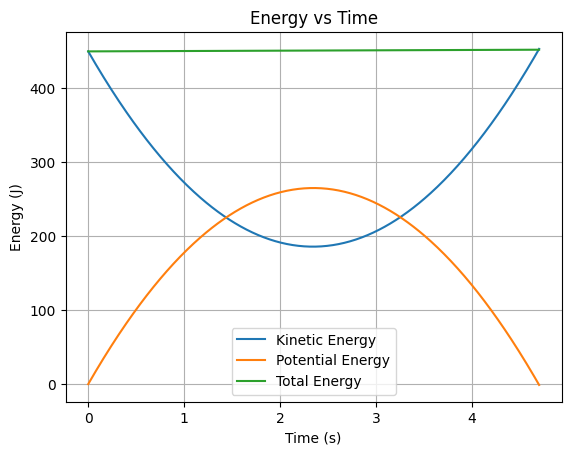

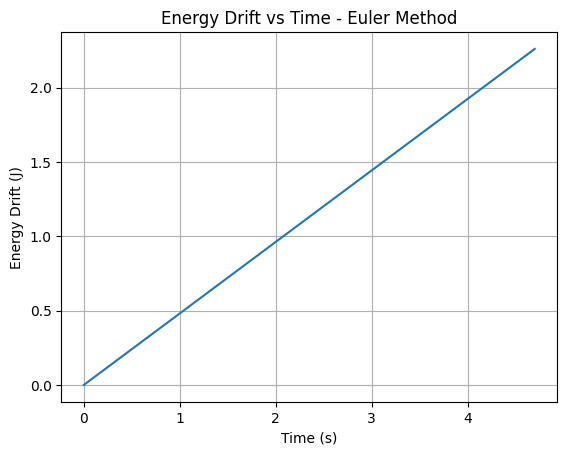

Part A

Initial total energy: 450.0 J
Maximum energy drift: 2.2615483499998845 J
Drift percentage: 0.5025662999999744 %


In [32]:
# PART A - ADD ENERGY TRACKING

# A1. PROJECTILE FUNCTION

def simulate_projectile(v0, angle_deg, dt, g=9.81, m=1.0):

    # First convert to radians
    angle_rad = np.radians(angle_deg)

    # Starting position and velocity
    t = 0
    x = 0
    y = 0
    vx = v0 * np.cos(angle_rad)
    vy = v0 * np.sin(angle_rad)

    # Starting energies
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    # Save values in lists
    times = [t]
    x_positions = [x]
    y_positions = [y]
    x_velocities = [vx]
    y_velocities = [vy]
    KE_values = [KE]
    PE_values = [PE]
    E_total_values = [E_total]

    # Calculate until the ball passes the ground
    while y >= 0:

        # Gravity is the only acceleration
        ax = 0
        ay = -g

        # Euler method
        x = x + vx * dt
        y = y + vy * dt
        vx = vx + ax * dt
        vy = vy + ay * dt
        t = t + dt

        # Recalculate energies
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        # Save new values
        times.append(t)
        x_positions.append(x)
        y_positions.append(y)
        x_velocities.append(vx)
        y_velocities.append(vy)
        KE_values.append(KE)
        PE_values.append(PE)
        E_total_values.append(E_total)

    return np.array(times), np.array(x_positions), np.array(y_positions), np.array(x_velocities), np.array(y_velocities), np.array(KE_values), np.array(PE_values), np.array(E_total_values)

# A2. VALUES

v0 = 30
angle = 50
dt = 0.01
g = 9.81
m = 1.0

# A3. RUN SIMULATION AND EXACT FREE FALL VALUES

t, x, y, vx, vy, KE, PE, E_total = simulate_projectile(v0, angle, dt, g, m)

# A4. PLOT ENERGY

plt.figure()

plt.plot(t, KE, label='Kinetic Energy')
plt.plot(t, PE, label='Potential Energy')
plt.plot(t, E_total, label='Total Energy')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy vs Time')
plt.legend()
plt.grid()
plt.show()

# A5. ENERGY DRIFT

energy_drift = E_total - E_total[0]

plt.figure()

plt.plot(t, energy_drift)
plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Energy Drift vs Time - Euler Method')
plt.grid()
plt.show()

# A6. ENERGY DRIFT RESULTS

max_drift = np.max(np.abs(energy_drift))

drift_percentage = (max_drift / abs(E_total[0])) * 100

print("Part A")
print()

print("Initial total energy:", E_total[0], "J")
print("Maximum energy drift:", max_drift, "J")
print("Drift percentage:", drift_percentage, "%")

### Part A Interpretation

The kinetic and potential energies almost flip throughout the projectie's flight. The total mechanical energy increases slightly over time. This energy drift demonstrates how the Euler method systematically introduces non-existent numerical energy into the system. Given that the drift energy at its maximum was 2.262 J, and the percentage was 0.503 %, the additional energy is almost negligible to the intial 450 J, but at a larger starting height, the system catastrophically create an overprediction.

## Part B - Euler vs. Euler-Cromer

In this part, we compare the standard Euler method with the Euler-Cromer method using the same projectile conditions and time step.

Euler final drift: 2.2615483499998845 J
Euler-Cromer final drift: -2.2519247400001063 J


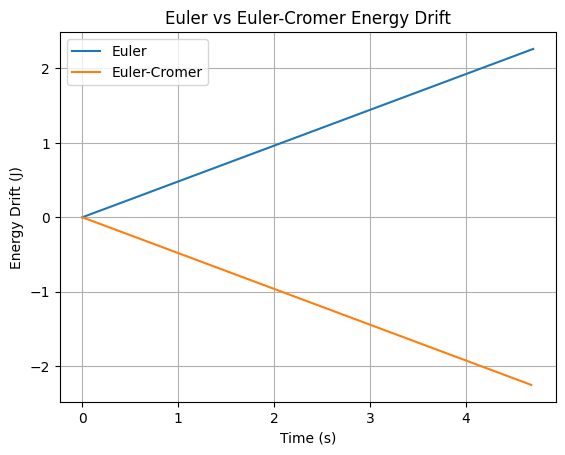

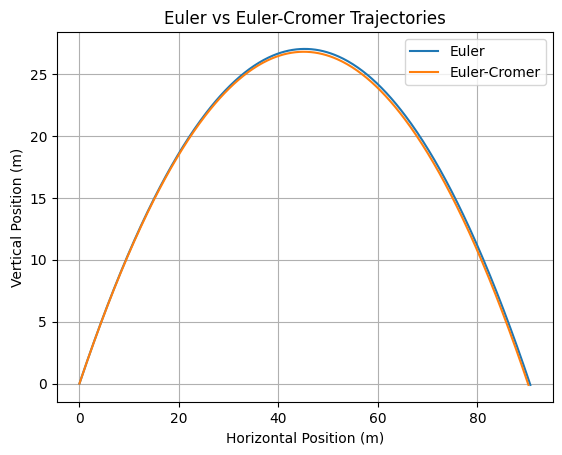


Euler landing range: 90.63305296580204 m
Euler-Cromer landing range: 90.24738039999012 m
Range difference: 0.385672565811916 m


In [33]:
# PART B - EULER VS EULER-CROMER

# B1. COMBINED PROJECTILE FUNCTION

def simulate(method, dt, v0=30, angle_deg=50, g=9.81, m=1.0):

    # First convert to radians
    angle_rad = np.radians(angle_deg)

    # Starting position and velocity
    t = 0
    x = 0
    y = 0
    vx = v0 * np.cos(angle_rad)
    vy = v0 * np.sin(angle_rad)

    # Starting energies
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    # Save values in lists
    times = [t]
    x_positions = [x]
    y_positions = [y]
    x_velocities = [vx]
    y_velocities = [vy]
    KE_values = [KE]
    PE_values = [PE]
    E_total_values = [E_total]

    # Calculate until the ball passes the ground
    while y >= 0:

        # Gravity is the only acceleration
        ax = 0
        ay = -g

        # Standard Euler
        if method == 'euler':

            x = x + vx * dt
            y = y + vy * dt

            vx = vx + ax * dt
            vy = vy + ay * dt

        # Euler-Cromer
        elif method == 'euler-cromer':

            vx = vx + ax * dt
            vy = vy + ay * dt

            x = x + vx * dt
            y = y + vy * dt

        else:
            raise ValueError("Method must be 'euler' or 'euler-cromer'")

        # Update time
        t = t + dt

        # Recalculate energies
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        # Save new values
        times.append(t)
        x_positions.append(x)
        y_positions.append(y)
        x_velocities.append(vx)
        y_velocities.append(vy)
        KE_values.append(KE)
        PE_values.append(PE)
        E_total_values.append(E_total)

    return (
        np.array(times),
        np.array(x_positions),
        np.array(y_positions),
        np.array(x_velocities),
        np.array(y_velocities),
        np.array(KE_values),
        np.array(PE_values),
        np.array(E_total_values)
    )

# B2. RUN BOTH METHODS

t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_total_e = simulate(
    'euler', dt, v0, angle, g, m
)

t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_total_ec = simulate(
    'euler-cromer', dt, v0, angle, g, m
)

# B3. CALCULATE ENERGY DRIFT

drift_e = E_total_e - E_total_e[0]
drift_ec = E_total_ec - E_total_ec[0]

print("Euler final drift:", drift_e[-1], "J")
print("Euler-Cromer final drift:", drift_ec[-1], "J")

# B4. PLOT ENERGY DRIFT

plt.figure()

plt.plot(t_e, drift_e, label='Euler')
plt.plot(t_ec, drift_ec, label='Euler-Cromer')

plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Euler vs Euler-Cromer Energy Drift')
plt.legend()
plt.grid()
plt.show()

# B5. PLOT TRAJECTORIES

plt.figure()

plt.plot(x_e, y_e, label='Euler')
plt.plot(x_ec, y_ec, label='Euler-Cromer')

plt.xlabel('Horizontal Position (m)')
plt.ylabel('Vertical Position (m)')
plt.title('Euler vs Euler-Cromer Trajectories')
plt.legend()
plt.grid()
plt.show()

# B6. LANDING RANGE COMPARISON

range_euler = x_e[-1]
range_ec = x_ec[-1]
range_difference = abs(range_euler - range_ec)

print()
print("Euler landing range:", range_euler, "m")
print("Euler-Cromer landing range:", range_ec, "m")
print("Range difference:", range_difference, "m")

### Part B Interpretation

The Euler and Euler-Cromer methods produced nearly identical trajectories, with a landing range differential of approx. 0.386 m. However, their energy errors were oppositive in that:

Euler gained approximately 2.262 J, whereas Euler-Cromer lost approximately 2.252 J.

This occurs because Euler updates the function's position using the old velocity, while the Euler-Cromer method uses the newly updated velocity. Given that gravity is constant, both methods calculate the velocity exactly, which causes their position and energy errors to be nearly equal in magnitude and opposite sign. All that being said, this test fails to sufficiently prove that the Euler-Cromer method is "more accurate" than standard the Euler method.

## Part C - Convergence Study

In this part, we test how the energy error is changed as we decrease the size of the time step. Both the Euler and Euler-Cromer methods run over identical time steps, and the corresponding maximum absolute energy drift is recorded for each case. We additonally create a log-log plot of the maximum energy drifts versus the time step.

Part C

dt = 0.1 s
Euler maximum drift: 23.096664000000033 J
Euler-Cromer maximum drift: 22.134303000000102 J

dt = 0.05 s
Euler maximum drift: 11.428036875000032 J
Euler-Cromer maximum drift: 11.187446625000064 J

dt = 0.025 s
Euler maximum drift: 5.683944656249821 J
Euler-Cromer maximum drift: 5.623797093750056 J

dt = 0.0125 s
Euler maximum drift: 2.8269354374999693 J
Euler-Cromer maximum drift: 2.8118985468749997 J

dt = 0.00625 s
Euler maximum drift: 1.411588107421835 J
Euler-Cromer maximum drift: 1.4078288847655926 J



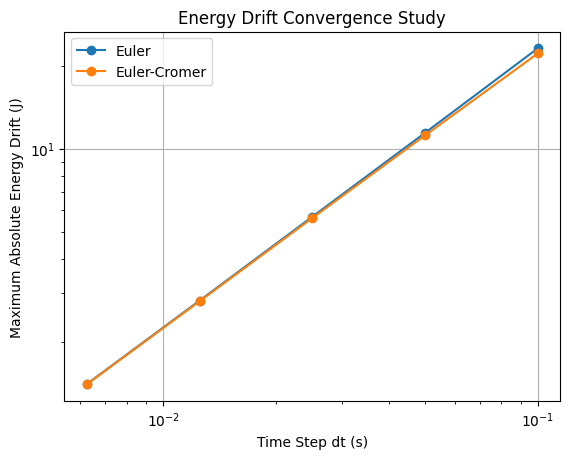

Euler slope: 1.0079853563067191
Euler-Cromer slope: 0.994174444641701

Euler drift percentages:
[5.132592   2.53956375 1.26309881 0.62820787 0.31368625]

Euler-Cromer drift percentages:
[4.918734   2.48609925 1.24973269 0.62486634 0.31285086]


In [34]:
# PART C - CONVERGENCE STUDY

# C1. TIME STEP VALUES

dts = np.array([
    0.1,
    0.05,
    0.025,
    0.0125,
    0.00625
])

# C2. SAVE MAXIMUM ENERGY DRIFT VALUES

euler_drifts = []
ec_drifts = []

# C3. RUN BOTH METHODS FOR EACH TIME STEP

for dt_test in dts:

    # Standard Euler
    t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_total_e = simulate(
        'euler', dt_test, v0, angle, g, m
    )

    drift_e = E_total_e - E_total_e[0]
    max_drift_e = np.max(np.abs(drift_e))

    euler_drifts.append(max_drift_e)


    # Euler-Cromer
    t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_total_ec = simulate(
        'euler-cromer', dt_test, v0, angle, g, m
    )

    drift_ec = E_total_ec - E_total_ec[0]
    max_drift_ec = np.max(np.abs(drift_ec))

    ec_drifts.append(max_drift_ec)

# Convert lists to arrays

euler_drifts = np.array(euler_drifts)
ec_drifts = np.array(ec_drifts)

# C4. PRINT ENERGY DRIFT VALUES

print("Part C")
print()

for i in range(len(dts)):

    print("dt =", dts[i], "s")
    print("Euler maximum drift:", euler_drifts[i], "J")
    print("Euler-Cromer maximum drift:", ec_drifts[i], "J")
    print()

# C5. LOG-LOG CONVERGENCE PLOT

plt.figure()

plt.loglog(
    dts,
    euler_drifts,
    'o-',
    label='Euler'
)

plt.loglog(
    dts,
    ec_drifts,
    'o-',
    label='Euler-Cromer'
)

plt.xlabel('Time Step dt (s)')
plt.ylabel('Maximum Absolute Energy Drift (J)')
plt.title('Energy Drift Convergence Study')
plt.legend()
plt.grid()

plt.show()

# C6. CALCULATE CONVERGENCE SLOPES

slope_euler = np.polyfit(
    np.log(dts),
    np.log(euler_drifts),
    1
)[0]

slope_ec = np.polyfit(
    np.log(dts),
    np.log(ec_drifts),
    1
)[0]

print("Euler slope:", slope_euler)
print("Euler-Cromer slope:", slope_ec)

# C7. CALCULATE ENERGY DRIFT PERCENTAGES

initial_energy = 0.5 * m * v0**2

euler_percent = (
    euler_drifts / initial_energy
) * 100

ec_percent = (
    ec_drifts / initial_energy
) * 100

print()
print("Euler drift percentages:")
print(euler_percent)

print()
print("Euler-Cromer drift percentages:")
print(ec_percent)

### Part C Analysis

1. The measured order of the Euler method was approximately 1.008, which agrees with the expected first-order convergenceas outlined in module notes. This means that halving the time step nearly halves the numerical energy error.

2. The Euler-Cromer method generated a slope of approximately 0.994, which is also first-order. Its maximum energy drift was nearly the same magnitude as Euler's at every tested time step. This is expectantly consistent with the earlier result being that uniform gravity is a preliminary example comparing the two methods.

3. None of the tested time steps conserved energy to within 0.01%. Even the smallest tested time step of dt = 0.00625 s only produced an energy drift of approximately 0.314% for Euler and 0.313% for Euler-Cromer. Altogether, a substantially smaller time step would be required to reach the 0.01% requirement.

## Bonus - Drag and Physical Energy Loss

In this section, we add Lab 1's quadratic air resistance back into the projectile simulation and use the Euler-Cromer method to update the motion. Unlike the case using only gravity, mechanical energy should now decrease because drag removes energy from the projectile. Finally we compare the total mechanical energy lost with the work done by the drag force.

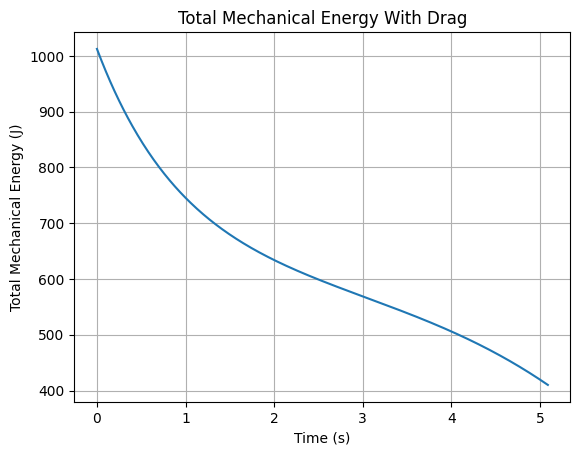

Bonus

Initial mechanical energy: 1012.4999999999998 J
Final mechanical energy: 410.00621733858287 J

Mechanical energy lost: 602.4937826614168 J
Work done against drag: 600.4898353185265 J

Difference: 2.003947342890342 J
Percent difference: 0.33260880038267543 %


In [35]:
# BONUS - DRAG AND PHYSICAL ENERGY LOSS

# BONUS 1. DRAG PROJECTILE FUNCTION

def simulate_drag_energy(v0, angle_deg, dt, g=9.81, m=1.0, b_over_m=0.0046):

    # First convert to radians
    angle_rad = np.radians(angle_deg)

    # Starting position and velocity
    t = 0
    x = 0
    y = 0

    vx = v0 * np.cos(angle_rad)
    vy = v0 * np.sin(angle_rad)

    # Starting energies
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    # Starting drag work
    drag_work = 0

    # Save values in lists
    times = [t]
    x_positions = [x]
    y_positions = [y]
    x_velocities = [vx]
    y_velocities = [vy]
    KE_values = [KE]
    PE_values = [PE]
    E_total_values = [E_total]
    drag_work_values = [drag_work]

    # Calculate until the ball passes the ground
    while y >= 0:

        # Calculate speed
        speed = np.sqrt(vx**2 + vy**2)

        # Calculate drag force
        F_drag_x = -m * b_over_m * speed * vx
        F_drag_y = -m * b_over_m * speed * vy

        # Calculate power from drag
        drag_power = (
            F_drag_x * vx
            + F_drag_y * vy
        )

        # Add work done by drag
        drag_work = drag_work + drag_power * dt

        # Calculate acceleration
        ax = F_drag_x / m
        ay = -g + F_drag_y / m

        # Euler-Cromer method
        vx = vx + ax * dt
        vy = vy + ay * dt

        x = x + vx * dt
        y = y + vy * dt

        # Update time
        t = t + dt

        # Recalculate energies
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        # Save new values
        times.append(t)
        x_positions.append(x)
        y_positions.append(y)
        x_velocities.append(vx)
        y_velocities.append(vy)
        KE_values.append(KE)
        PE_values.append(PE)
        E_total_values.append(E_total)
        drag_work_values.append(drag_work)


    # Convert lists to arrays

    return (
        np.array(times),
        np.array(x_positions),
        np.array(y_positions),
        np.array(x_velocities),
        np.array(y_velocities),
        np.array(KE_values),
        np.array(PE_values),
        np.array(E_total_values),
        np.array(drag_work_values)
    )

# BONUS 2. VALUES

v0_bonus = 45
angle_bonus = 40
dt_bonus = 0.01
g = 9.81
m = 1.0
b_over_m = 0.0046

# BONUS 3. RUN SIMULATION

t_drag, x_drag, y_drag, vx_drag, vy_drag, KE_drag, PE_drag, E_total_drag, drag_work = simulate_drag_energy(
    v0_bonus,
    angle_bonus,
    dt_bonus,
    g,
    m,
    b_over_m
)

# BONUS 4. PLOT TOTAL ENERGY

plt.figure()

plt.plot(
    t_drag,
    E_total_drag
)

plt.xlabel('Time (s)')
plt.ylabel('Total Mechanical Energy (J)')
plt.title('Total Mechanical Energy With Drag')
plt.grid()

plt.show()

# BONUS 5. CALCULATE ENERGY LOST

energy_lost = (E_total_drag[0] - E_total_drag[-1])

# BONUS 6. CALCULATE WORK DONE BY DRAG

work_done_by_drag = drag_work[-1]
work_against_drag = -work_done_by_drag

# BONUS 7. COMPARE ENERGY LOSS AND DRAG WORK

difference = abs(
    energy_lost
    - work_against_drag
)

percent_difference = (
    difference / energy_lost
) * 100

# BONUS 8. PRINT RESULTS

print("Bonus")
print()

print("Initial mechanical energy:", E_total_drag[0], "J")
print("Final mechanical energy:", E_total_drag[-1], "J")

print()

print("Mechanical energy lost:", energy_lost, "J")
print("Work done against drag:", work_against_drag, "J")

print()

print("Difference:", difference, "J")
print("Percent difference:", percent_difference, "%")

### Bonus Interpretation

With quadratic air drag included, the total mechanical energy is decreased throughout the flight. This shows that the energy was physically dissipated by the drag force. During the simulation, the projectile lost approx. 602.494 J of mechanical energy, whereas the calculated work done against drag was approx. 600.490 J.

The overall difference between these values was approx. 2.004 J, or 0.333%. This very close agreement demonstrates how the work-energy theorem is functional numerically. Additionally, this shows observed energy loss is primarily physical energy dissipation from drag rather than numerical error!

## Tools and Assistance

This week's task was far easier for me to work through than last week, plainly because I took the time to first formulate a plan. In that way, AI was a phenomenal help in establish a game plan from translating the HTML to a step by step .md file! 

One thing I often forget when coding is that it is ultimately a translation of problem solving. 

Furthermore, I utilized the "suggestions feature" (Not "Generation Feature") of VS Code to speed up my output, and ultimately found it to be an enjoyable experience! This week, I was able to put far more of my effort toward learning the physical phenomena rather than the code, which is the ultimate goal!